In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

/Users/andyzhu/PycharmProjects/Kaggle_Spaceship_Titanic/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
train = pd.read_csv("Tables/train.csv", index_col="PassengerId")
test = pd.read_csv("Tables/test.csv", index_col="PassengerId")

In [19]:
# Beide Indizes (PassengerId) kombinieren
all_groups = train.index.append(test.index).str.split("_").str[0]

# Gruppengröße über kombinierte Daten berechnen
group_sizes = all_groups.value_counts()

# Zurück auf train und test mappen
train["Group"] = train.index.str.split("_").str[0]
train["GroupSize"] = train["Group"].map(group_sizes)

test["Group"] = test.index.str.split("_").str[0]
test["GroupSize"] = test["Group"].map(group_sizes)

In [3]:
report = sv.analyze(train, target_feat="Transported")

Feature: Transported (TARGET)                |▋         | [  7%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: HomePlanet                          |██        | [ 20%]   00:00 -> (00:03 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: CryoSleep                           |██▋       | [ 27%]   00:00 -> (00:03 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Destina

In [4]:
report.show_html("report.html")

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
train.info()

<class 'pandas.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   str    
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   str    
 3   Destination   8511 non-null   str    
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   str    
 12  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(4)
memory usage: 891.4+ KB


In [7]:
split_cols = train["Cabin"].str.split("/", expand=True)

train["Deck"] = split_cols[0]
train["Num"] = split_cols[1].astype(float)  # float wegen NaNs
train["Side"] = split_cols[2]

In [10]:
train.Deck.value_counts()

Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

<Axes: xlabel='Deck'>

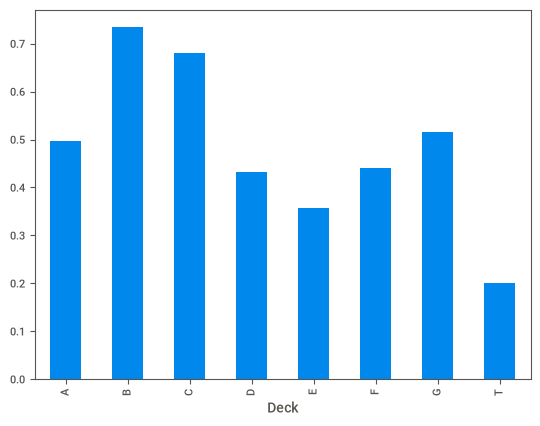

In [9]:
train.groupby("Deck")["Transported"].mean().plot(kind="bar")

<Axes: xlabel='Side'>

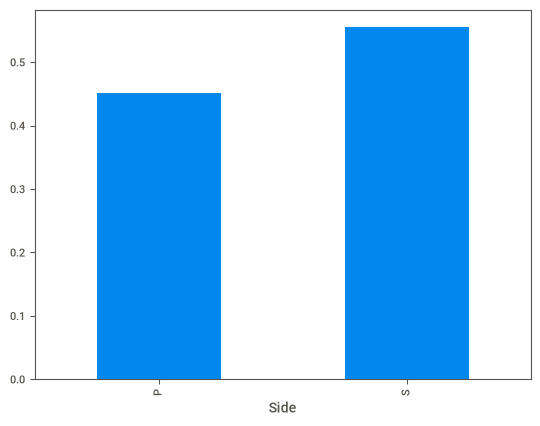

In [12]:
train.groupby("Side")["Transported"].mean().plot(kind="bar")

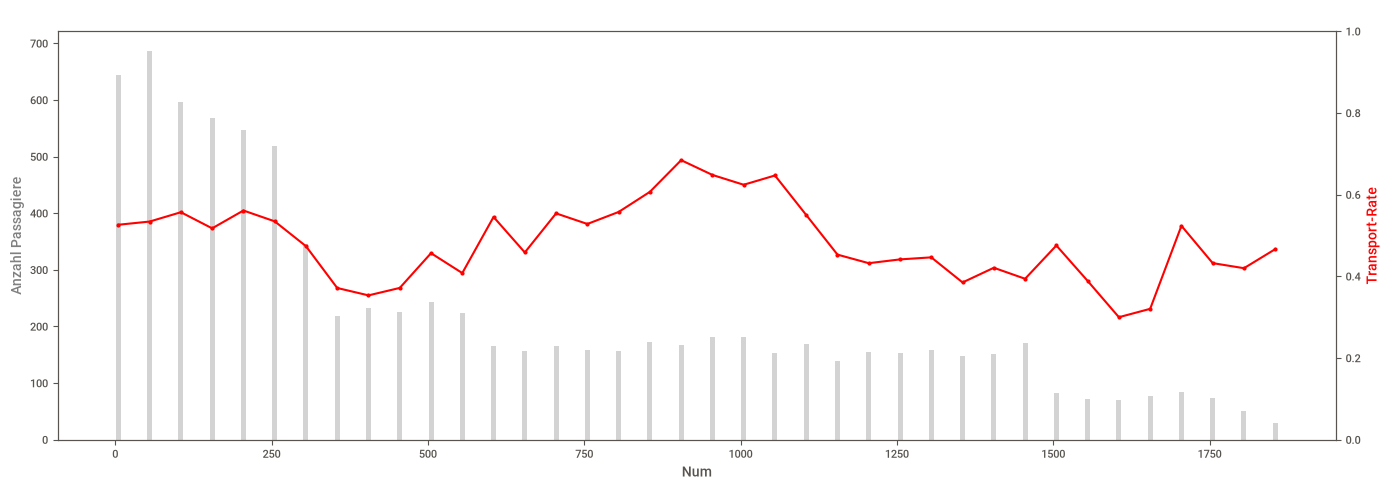

In [16]:
max_num = train["Num"].max()
bins = np.arange(0, max_num + 50, 50)
train["Num_bin"] = pd.cut(train["Num"], bins=bins, right=False)

# Pro Bin: Anzahl und durchschnittliche Transport-Rate
grouped = train.groupby("Num_bin")["Transported"].agg(["count", "mean"])

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

bin_centers = bins[:-1] + 5  # Mittelpunkte der Bins für die X-Achse

ax1.bar(bin_centers, grouped["count"], width=8, color="lightgray", label="Anzahl")
ax1.set_xlabel("Num")
ax1.set_ylabel("Anzahl Passagiere", color="gray")

ax2 = ax1.twinx()
ax2.plot(bin_centers, grouped["mean"], color="red", marker="o", markersize=2, label="Transport-Rate")
ax2.set_ylabel("Transport-Rate", color="red")
ax2.set_ylim(0, 1)

plt.title("Verteilung von Num und Transport-Rate pro Bin")
fig.tight_layout()
plt.show()

In [20]:
train.GroupSize.value_counts()

GroupSize
1    4805
2    1682
3    1020
4     412
5     265
7     231
6     174
8     104
Name: count, dtype: int64

<Axes: xlabel='GroupSize'>

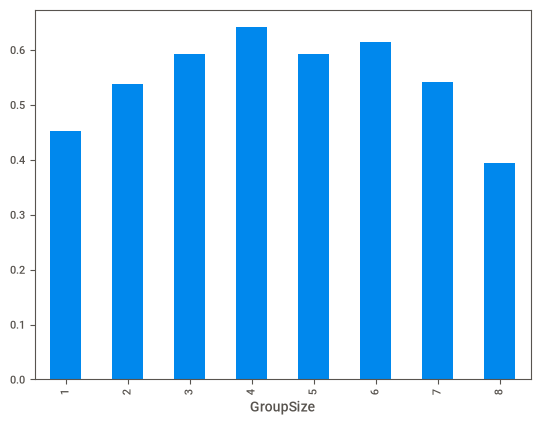

In [25]:
train.groupby("GroupSize")["Transported"].mean().plot(kind="bar")

In [23]:
train.VIP.value_counts()

VIP
False    8291
True      199
Name: count, dtype: int64